In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
import torch
torch.cuda.empty_cache()
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import linalg as la
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
#from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch


print (torch.__version__, torch.cuda.is_available())
print(torch.version.cuda)
print (torch.cuda.get_device_name())
# device= 'cpu'
device= 'cuda'

2.3.1 True
11.8
NVIDIA GeForce RTX 3070 Ti


In [2]:
import torch
torch.cuda.empty_cache()

In [3]:
def ou_process_1d(theta=1, mu=0, sigma=1, X0=0, n_steps=10000, n_eval=200, h=1e-5):
    """
    Simulates the Ornstein-Uhlenbeck process.
    
    Parameters:
    - theta: rate of mean reversion
    - mu: long-term mean of the process
    - sigma: volatility
    - X0: initial value
    - n_steps: number of steps in each evaluation
    - n_eval: number of evaluations
    - h: Integration step size
    
    Returns:
    - A numpy array containing the simulated values at each evaluation
    """
    X_eval = np.zeros(n_eval)
    X = X0
    
    for i in range(n_eval):
        for _ in range(n_steps):
            dW = np.sqrt(h) * np.random.randn()
            X = X + theta * (mu - X) * h + sigma * dW
        X_eval[i] = X
    
    return X_eval

## Setup the parameters
theta = 1
mu = 0
sigma = 0.1

In [4]:
# Generate m initial points from the domain space [-2, 2]
m = 10
n_eval = 200
n_steps = 1000
h = 1e-4
lag_time = n_steps * h
print("lag time: ", lag_time)
X0_values = np.linspace(-2, 2, m)

# Initialize the data_matrix
data_matrix = np.zeros((m, n_eval+1, 1))

# Simulate trajectories for each initial point and store them in the data_matrix
for i, X0 in tqdm(enumerate(X0_values), total=m, desc="Simulating trajectories"):
    X_eval = np.concatenate(([X0], ou_process_1d(X0=X0, n_steps=n_steps, n_eval=n_eval, h=h)))
    data_matrix[i, :, 0] = X_eval

# Print the shape of data_matrix
print("Shape of data_matrix:", data_matrix.shape)

# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]
data_x_train = X[:int(0.7*len_all)]
data_x_valid = X[int(0.7*len_all)+1:]

data_y_train = Y[:int(0.7*len_all)]
data_y_valid = Y[int(0.7*len_all)+1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print(data_x_train.shape)

lag time:  0.1


Simulating trajectories: 100%|██████████| 10/10 [00:02<00:00,  3.62it/s]

Shape of data_matrix: (10, 201, 1)
Shape of data_X: (10, 200, 1)
Shape of data_Y: (10, 200, 1)
Shape of X: (2000, 1)
Shape of Y: (2000, 1)
(1400, 1)


In [ ]:
from solver_edmd_torch_gpu import KoopmanNNTorch, EDMDSolverTorch
#### EDMD Test ####
checkpoint_file= 'ou1d_example_ckpt003.torch'

basis_function = KoopmanNNTorch(input_size=1, layer_sizes=[20, 20], n_psi_train=18).to(device)

solver = EDMDSolverTorch(
    dic=basis_function,
    target_dim=np.shape(data_x_train)[-1],
    reg=0.1,
    checkpoint_file=checkpoint_file,
    batch_size=32
)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

In [8]:
solver.build_with_edmd(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=0.8
)

Outer Epoch 1/6
Epoch: 1 	Training Loss: 0.006749 val loss: 0.006313
saving, val loss enhanced: 0.006312501151995022 1000000000000000.0
Epoch: 2 	Training Loss: 0.006737 val loss: 0.006302
saving, val loss enhanced: 0.006301501678275098 0.006312501151995022
Epoch: 3 	Training Loss: 0.006726 val loss: 0.006291
saving, val loss enhanced: 0.006290587205148428 0.006301501678275098
Outer Epoch 2/6
Epoch: 1 	Training Loss: 0.006713 val loss: 0.006281
saving, val loss enhanced: 0.00628068756870586 0.006290587205148428
Epoch: 2 	Training Loss: 0.006702 val loss: 0.006270
saving, val loss enhanced: 0.006269563224483732 0.00628068756870586
Epoch: 3 	Training Loss: 0.006690 val loss: 0.006259
saving, val loss enhanced: 0.006258818190227247 0.006269563224483732
Outer Epoch 3/6
Epoch: 1 	Training Loss: 0.006679 val loss: 0.006249
saving, val loss enhanced: 0.006249117956484614 0.006258818190227247
Epoch: 2 	Training Loss: 0.006667 val loss: 0.006239
saving, val loss enhanced: 0.006238531386007916 0

In [ ]:
# Results from solver_edmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    'K': Koopman_matrix_K
    }

[-3.62898150e-04+0.j -9.49685766e-01+0.j -3.51691657e+00+0.j
 -7.28140948e+00+0.j]


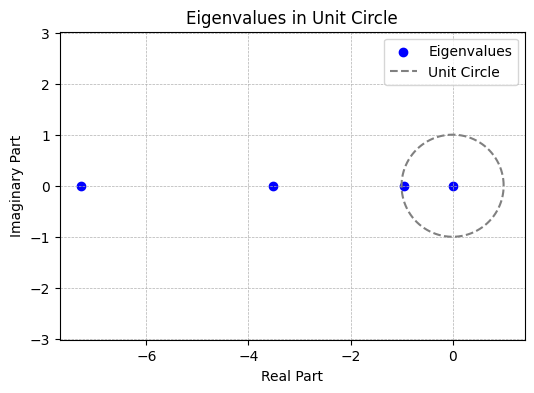

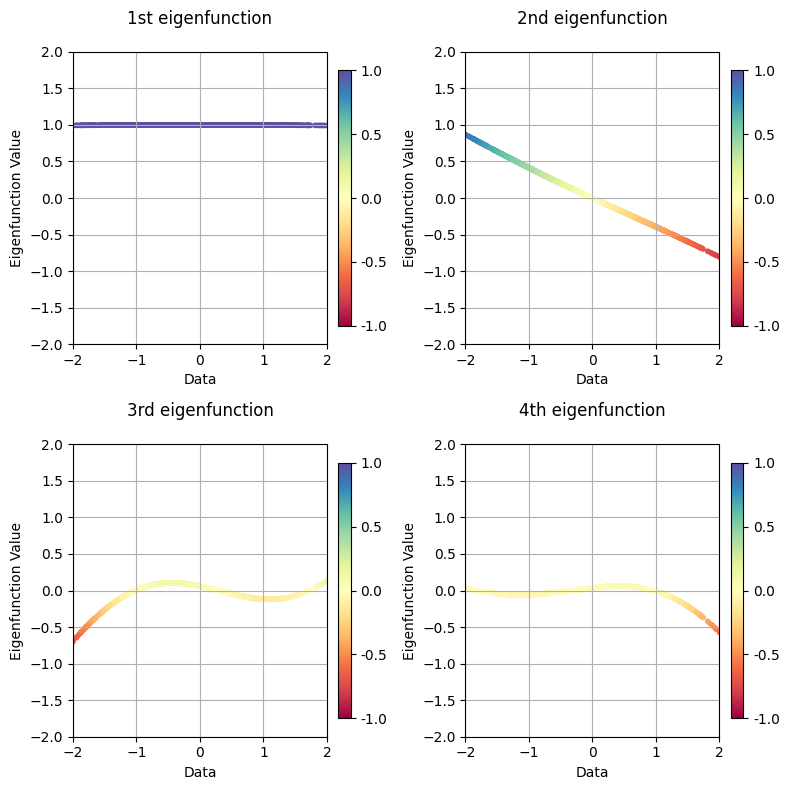

In [10]:
# Take ln values of the eigenvalues and divide by 0.1
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues = (evalues[:4]-1) / lag_time

print(ln_evalues)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues.real
imag_parts = ln_evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('SDMD', fontsize=20)
plt.tight_layout()
plt.show()

In [5]:
from solver_sdmd_torch_gpu2 import KoopmanNNTorch, KoopmanSolverTorch
#### SDMD Test ####
checkpoint_file= 'ou1d_example_ckpt002.torch'

basis_function = KoopmanNNTorch(input_size=1, layer_sizes=[20, 20], n_psi_train=18).to(device)

solver = KoopmanSolverTorch(dic=basis_function, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                       reg=0.1,  checkpoint_file= checkpoint_file, fnn_checkpoint_file= 'example_fnn_ou_001.torch', a_b_file= 'a_b_example_ou.jbl',
                generator_batch_size= 4, fnn_batch_size= 32, delta_t= lag_time)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

In [ ]:
solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8
    )

Epoch: 1 	Training Loss: 0.390616 	Validation Loss: 0.239996
Saving model, validation loss improved: 0.239996 < 10000.000000
Epoch: 2 	Training Loss: 0.220808 	Validation Loss: 0.142848
Saving model, validation loss improved: 0.142848 < 0.239996
Epoch: 3 	Training Loss: 0.138656 	Validation Loss: 0.107447
Saving model, validation loss improved: 0.107447 < 0.142848
Epoch: 4 	Training Loss: 0.111295 	Validation Loss: 0.100660
Saving model, validation loss improved: 0.100660 < 0.107447
Epoch: 5 	Training Loss: 0.106701 	Validation Loss: 0.099774
Saving model, validation loss improved: 0.099774 < 0.100660
Epoch: 6 	Training Loss: 0.106638 	Validation Loss: 0.099444
Saving model, validation loss improved: 0.099444 < 0.099774
Epoch: 7 	Training Loss: 0.105630 	Validation Loss: 0.098726
Saving model, validation loss improved: 0.098726 < 0.099444
Epoch: 8 	Training Loss: 0.104514 	Validation Loss: 0.098551
Saving model, validation loss improved: 0.098551 < 0.098726
Epoch: 9 	Training Loss: 0.1

Processing batches:   0%|          | 0/22 [00:00<?, ?batch/s]c:\Users\xyc93\AppData\Local\anaconda3\envs\myvenvtorch\lib\site-packages\torch\_functorch\deprecated.py:61: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.vmap is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.vmap instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('vmap', 'torch.vmap')
Processing batches: 100%|██████████| 22/22 [00:00<00:00, 162.68batch/s]


saving FNN a and b to:  a_b_example_ou.jbl
Outer Epoch 1/6


Processing batches: 100%|██████████| 22/22 [00:00<00:00, 183.90batch/s]
c:\Users\xyc93\AppData\Local\anaconda3\envs\myvenvtorch\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch: 1 	Training Loss: 0.009080 val loss: 0.008941
Saving model, val loss improved from 1000000000000000.000000 to 0.008941
Epoch: 2 	Training Loss: 0.009057 val loss: 0.008919
Saving model, val loss improved from 0.008941 to 0.008919
EarlyStopping counter: 1 out of 7
Epoch 1 time: 0.21 seconds
Outer Epoch 2/6


...

Epoch: 1 	Training Loss: 0.008915 val loss: 0.008790
Saving model, val loss improved from 0.008806 to 0.008790


Epoch: 2 	Training Loss: 0.008893 val loss: 0.008769
Saving model, val loss improved from 0.008790 to 0.008769
EarlyStopping counter: 1 out of 7
Epoch 5 time: 0.22 seconds
Outer Epoch 6/6


Processing batches: 100%|██████████| 22/22 [00:00<00:00, 187.96batch/s]

Epoch: 1 	Training Loss: 0.008876 val loss: 0.008754
Saving model, val loss improved from 0.008769 to 0.008754
Epoch: 2 	Training Loss: 0.008854 val loss: 0.008734
Saving model, val loss improved from 0.008754 to 0.008734


EarlyStopping counter: 1 out of 7
Epoch 6 time: 0.20 seconds


In [7]:
# Results from solver_edmd/solver_resdmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    'K': Koopman_matrix_K
    }

[-5.75892737e-05+0.j -1.03753149e+00+0.j -2.23424145e+00+0.j
 -3.88774292e+00+0.j]


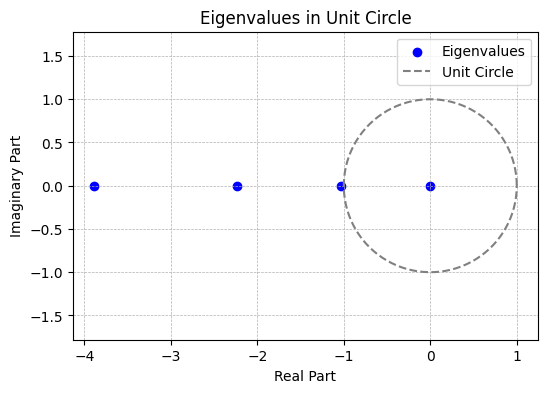

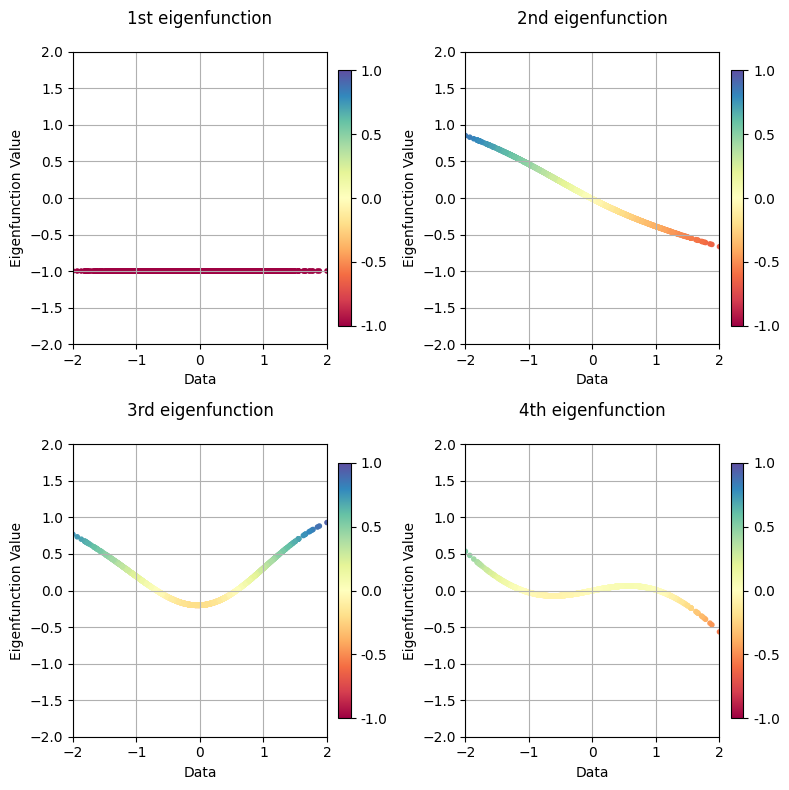

In [8]:
# Take ln values of the eigenvalues and divide by 0.1
# ln_evalues = np.log(evalues[:4]) / lag_time
ln_evalues = (evalues[:4]-1) / lag_time

print(ln_evalues)

## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = ln_evalues.real
imag_parts = ln_evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('SDMD', fontsize=20)
plt.tight_layout()
plt.show()

In [9]:
from solver_gedmd_torch_gpu import KoopmanNNTorch as KoopmanNNTorch_g
from solver_gedmd_torch_gpu import  KoopmanSolverTorch as KoopmanSolverTorch_g
#### gEDMD Test ####
basis_function_g = KoopmanNNTorch_g(input_size=1, layer_sizes=[20, 20], n_psi_train=18).to(device)

solver_g = KoopmanSolverTorch_g(dic=basis_function, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                       reg=0.1,  checkpoint_file= checkpoint_file, fnn_checkpoint_file= 'example_fnn_ou_001.torch',  a_b_file= 'a_b_example_ou.jbl',
                generator_batch_size= 4, fnn_batch_size= 32)

In [10]:
solver_g.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=32,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8,   
    )

Epoch: 1 	Training Loss: 0.352342 	Validation Loss: 0.262791
Saving model, validation loss improved: 0.262791 < 10000.000000
Epoch: 2 	Training Loss: 0.194043 	Validation Loss: 0.162041
Saving model, validation loss improved: 0.162041 < 0.262791
Epoch: 3 	Training Loss: 0.127553 	Validation Loss: 0.125966
Saving model, validation loss improved: 0.125966 < 0.162041
Epoch: 4 	Training Loss: 0.106790 	Validation Loss: 0.117170
Saving model, validation loss improved: 0.117170 < 0.125966
Epoch: 5 	Training Loss: 0.102129 	Validation Loss: 0.115620
Saving model, validation loss improved: 0.115620 < 0.117170
Epoch: 6 	Training Loss: 0.101340 	Validation Loss: 0.114812
Saving model, validation loss improved: 0.114812 < 0.115620
Epoch: 7 	Training Loss: 0.100138 	Validation Loss: 0.114000
Saving model, validation loss improved: 0.114000 < 0.114812
Epoch: 8 	Training Loss: 0.099802 	Validation Loss: 0.113338
Saving model, validation loss improved: 0.113338 < 0.114000
Epoch: 9 	Training Loss: 0.0

c:\Users\xyc93\AppData\Local\anaconda3\envs\myvenvtorch\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
Processing batches:   0%|          | 0/22 [00:00<?, ?batch/s]c:\Users\xyc93\AppData\Local\anaconda3\envs\myvenvtorch\lib\site-packages\torch\_functorch\deprecated.py:61: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.vmap is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.vmap instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('vmap', 'torch.vmap')
Processing batches: 100%|██████████| 22/22 [00:00<00:00, 140.10batch/s]


Epoch 1/6, gEDMD loss: 4.378909e-03
Saving best model at epoch 1


Processing batches: 100%|██████████| 22/22 [00:00<00:00, 143.42batch/s]


EarlyStopping counter: 1 out of 7


...

Processing batches: 100%|██████████| 22/22 [00:00<00:00, 164.64batch/s]


EarlyStopping counter: 4 out of 7


Processing batches: 100%|██████████| 22/22 [00:00<00:00, 164.24batch/s]

EarlyStopping counter: 5 out of 7


([0.004378908964085631,
  0.004380273241739325,
  0.004381639560803736,
  0.004383007815651641,
  0.004384377900521913,
  0.004385749709754397],
 0.004378908964085631)

In [11]:
solver_g.eig_decomp()  # Do spectral decomposition to generate eigenvalues and eigenvectors

evalues = solver_g.eigenvalues.T
efuns = solver_g.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Psi_X = solver_g.get_Psi_X()
Psi_Y = solver_g.get_Psi_Y()
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict
}

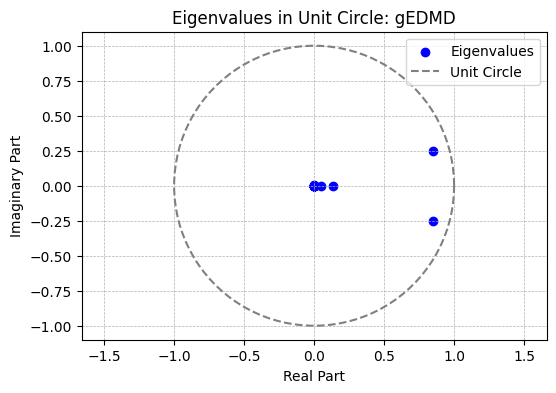

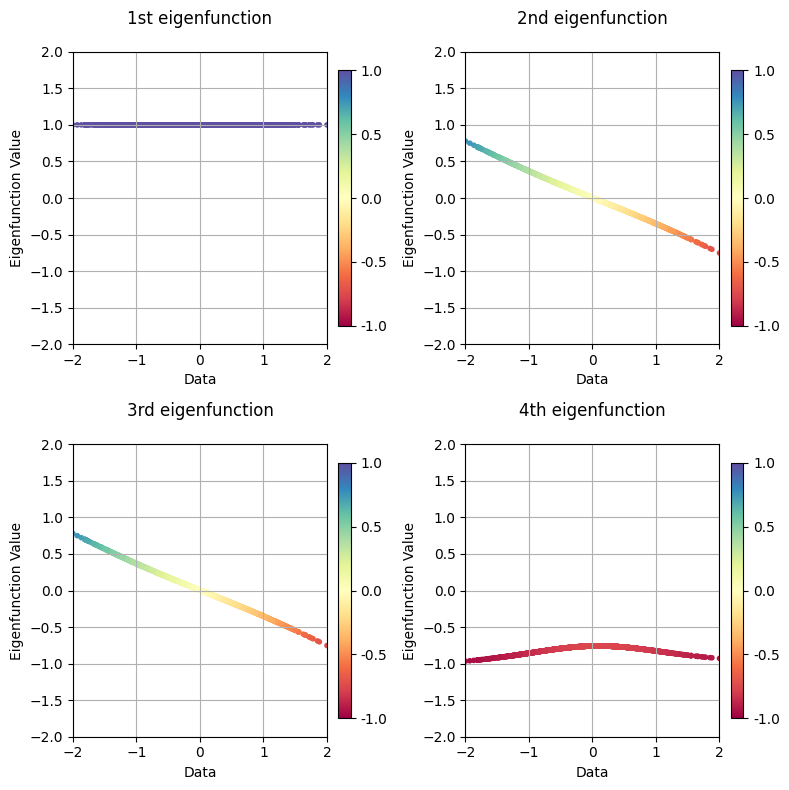

In [12]:
## Plot eigenvalues on unit circle
# Assuming evalues is a numpy array of complex numbers
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('Eigenvalues in Unit Circle: gEDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

## Plot eigenfunctions
# Get the real part of eigenfunctions and normalize them
phi = np.real(efuns)

# Use the entire efuns instead of slicing
for i in range(len(evalues)):
    phi[:, i] = phi[:, i] / np.max(np.abs(phi[:, i]))

# Create a plot with 2x2 layout
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
titles = ['1st eigenfunction', '2nd eigenfunction', '3rd eigenfunction', '4th eigenfunction']

# Determine global min and max values for the eigenfunctions for a uniform scale
vmin = np.min(phi)
vmax = np.max(phi)
cbar_ticks = np.linspace(vmin, vmax, 5)

# Flatten the 2D array of axes for easy iteration
axs_flat = axs.flatten()

for i, (ax, title) in enumerate(zip(axs_flat, titles)):
    scatter = ax.scatter(X, phi[:, i], c=phi[:, i], cmap='Spectral', marker='.', vmin=vmin, vmax=vmax)
    ax.set_title(title, pad=20)
    ax.set_xlabel('Data')
    ax.set_ylabel('Eigenfunction Value')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_ticklabels([f"{tick:.1f}" for tick in cbar_ticks])
    ax.grid()
# fig.suptitle('gEDMD', fontsize=20)
plt.tight_layout()
plt.show()